# Project Deliverable 2: Regression Modeling and Performance Evaluation
**Dataset:** Pima Indians Diabetes Dataset  
**Target Variable:** `Glucose` (continuous — treated as regression target)  
**Goal:** Predict plasma glucose concentration using feature engineering, multiple regression models, cross-validation, and thorough evaluation.


In [1]:
# ── Standard library & data manipulation
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# ── Sklearn – preprocessing & models
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("All libraries imported successfully.")


All libraries imported successfully.


## 1. Load & Explore the Dataset

In [2]:
# Load the Pima Indians Diabetes dataset
df = pd.read_csv('diabetes.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()


Shape: (768, 9)
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Basic statistics
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std','min','max'])


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000000,3.845052,3.369578,0.000000,1.000000,3.000000,6.000000,17.000000
Glucose,768.000000,120.894531,31.972618,0.000000,99.000000,117.000000,140.250000,199.000000
BloodPressure,768.000000,69.105469,19.355807,0.000000,62.000000,72.000000,80.000000,122.000000
SkinThickness,768.000000,20.536458,15.952218,0.000000,0.000000,23.000000,32.000000,99.000000
Insulin,768.000000,79.799479,115.244002,0.000000,0.000000,30.500000,127.250000,846.000000
BMI,768.000000,31.992578,7.884160,0.000000,27.300000,32.000000,36.600000,67.100000
DiabetesPedigreeFunction,768.000000,0.471876,0.331329,0.078000,0.243750,0.372500,0.626250,2.420000
Age,768.000000,33.240885,11.760232,21.000000,24.000000,29.000000,41.000000,81.000000
Outcome,768.000000,0.348958,0.476951,0.000000,0.000000,0.000000,1.000000,1.000000


In [4]:
# Check for zero values that are biologically impossible (act as hidden NaN)
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Zero counts per column (likely missing values):")
print((df[zero_cols] == 0).sum())


Zero counts per column (likely missing values):
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


## 2. Feature Engineering
We apply several transformations to improve model performance:

1. **Impute zeros** — replace biologically impossible zeros with the column median  
2. **BMI category** — ordinal encoding of underweight / normal / overweight / obese  
3. **Interaction feature** — `BMI × Pregnancies` captures joint effect  
4. **Log transform Insulin** — heavily right-skewed; log normalization helps linear models  
5. **Age bins** — discretize age into young / middle / senior groups (ordinal)  


In [5]:
# ── Step 1: Replace impossible zeros with column median
df_eng = df.copy()
zero_cols = ['BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_cols:
    median_val = df_eng[col][df_eng[col] != 0].median()
    df_eng[col] = df_eng[col].replace(0, median_val)
    print(f"  {col}: replaced zeros with median = {median_val:.2f}")

print()

# ── Step 2: BMI category (ordinal)
def bmi_category(bmi):
    if bmi < 18.5:  return 0   # Underweight
    elif bmi < 25:  return 1   # Normal
    elif bmi < 30:  return 2   # Overweight
    else:           return 3   # Obese

df_eng['BMI_Category'] = df_eng['BMI'].apply(bmi_category)
print("BMI Category distribution:")
print(df_eng['BMI_Category'].value_counts().sort_index())

# ── Step 3: BMI × Pregnancies interaction
df_eng['BMI_x_Pregnancies'] = df_eng['BMI'] * df_eng['Pregnancies']

# ── Step 4: Log-transform Insulin (add 1 to avoid log(0))
df_eng['Log_Insulin'] = np.log1p(df_eng['Insulin'])

# ── Step 5: Age bins
df_eng['Age_Group'] = pd.cut(df_eng['Age'],
                              bins=[0, 30, 45, 100],
                              labels=[0, 1, 2]).astype(int)

print()
print("Engineered feature columns:", ['BMI_Category','BMI_x_Pregnancies','Log_Insulin','Age_Group'])
df_eng.head()


  BloodPressure: replaced zeros with median = 72.00
  SkinThickness: replaced zeros with median = 29.00
  Insulin: replaced zeros with median = 125.00
  BMI: replaced zeros with median = 32.30

BMI Category distribution:
BMI_Category
0      4
1    102
2    179
3    483
Name: count, dtype: int64

Engineered feature columns: ['BMI_Category', 'BMI_x_Pregnancies', 'Log_Insulin', 'Age_Group']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,BMI_x_Pregnancies,Log_Insulin,Age_Group
0,6,148,72,35,125,33.6,0.627,50,1,3,201.6,4.836282,2
1,1,85,66,29,125,26.6,0.351,31,0,2,26.6,4.836282,1
2,8,183,64,29,125,23.3,0.672,32,1,1,186.4,4.836282,1
3,1,89,66,23,94,28.1,0.167,21,0,2,28.1,4.553877,0
4,0,137,40,35,168,43.1,2.288,33,1,3,0.0,5.129899,1


## 3. Exploratory Visualizations

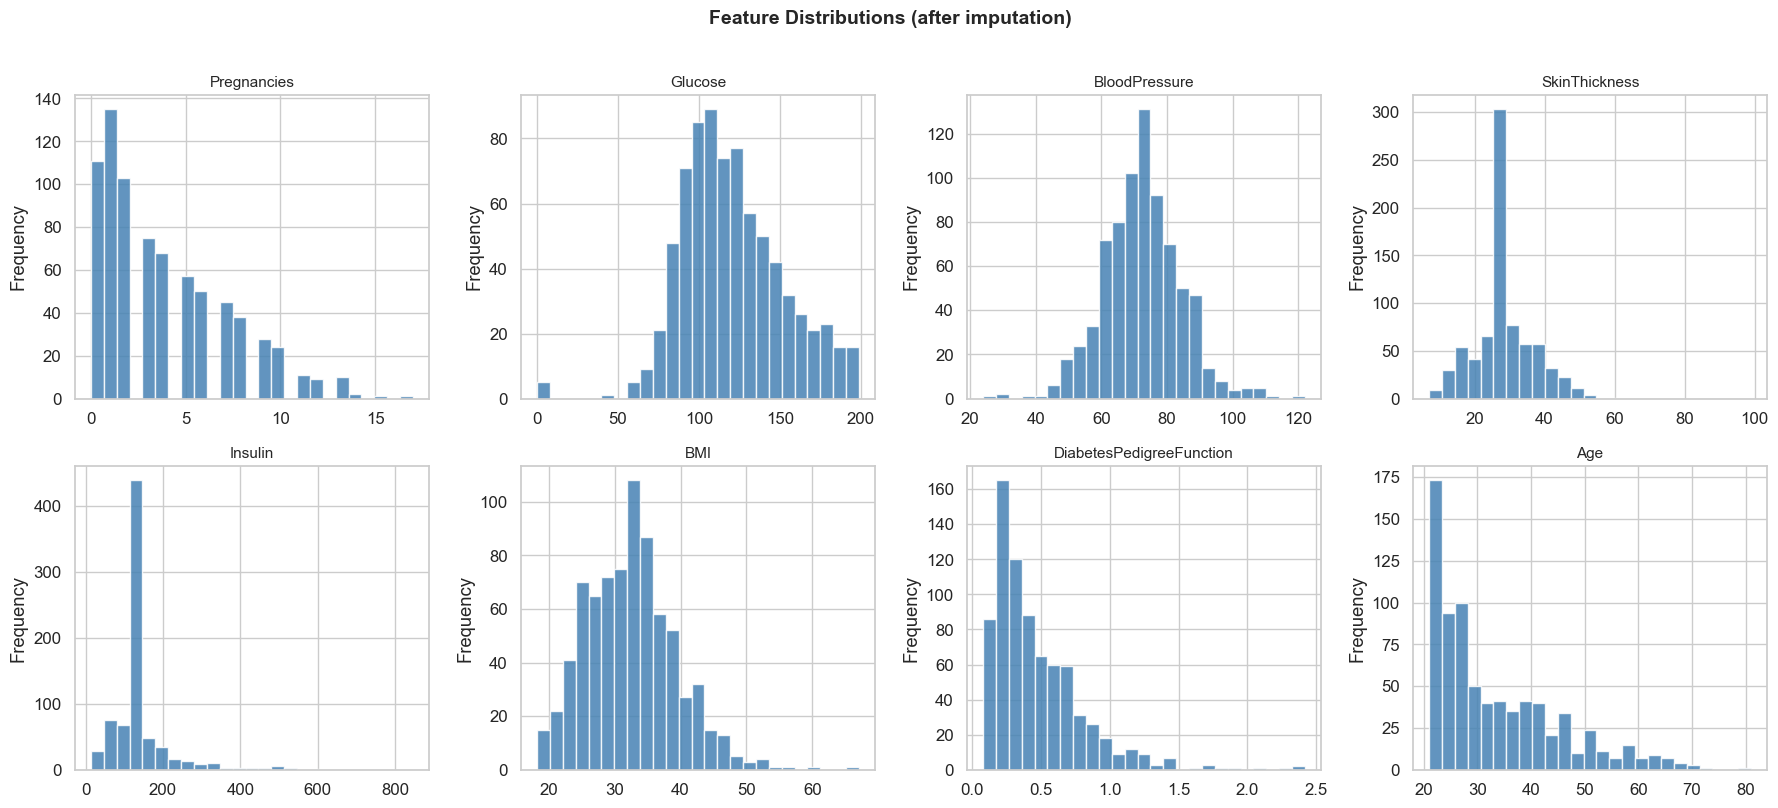

Saved: feature_distributions.png


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

num_cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigreeFunction','Age']

for i, col in enumerate(num_cols):
    axes[i].hist(df_eng[col], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions (after imputation)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: feature_distributions.png")


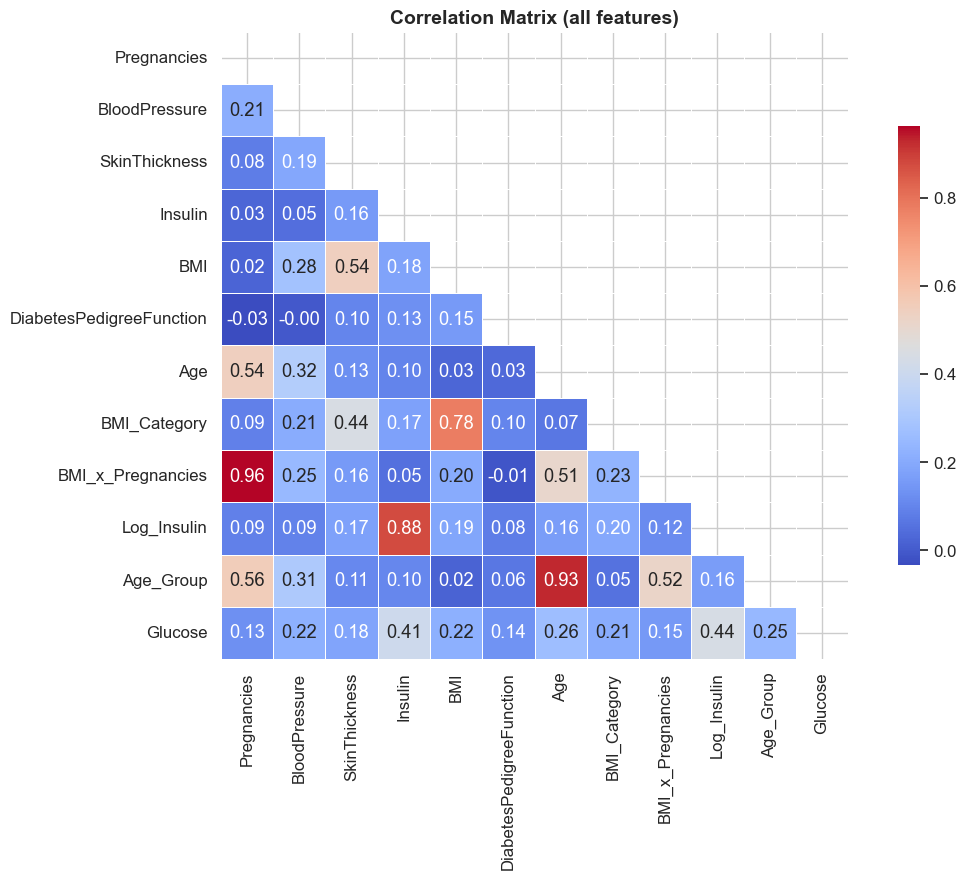

Saved: correlation_heatmap.png


In [7]:
# Correlation heatmap – all features vs Glucose
feature_cols = ['Pregnancies','BloodPressure','SkinThickness','Insulin',
                'BMI','DiabetesPedigreeFunction','Age',
                'BMI_Category','BMI_x_Pregnancies','Log_Insulin','Age_Group','Glucose']

corr = df_eng[feature_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.7})
plt.title('Correlation Matrix (all features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: correlation_heatmap.png")


## 4. Prepare Feature Matrix and Target

In [8]:
# Target: Glucose (continuous variable)
TARGET = 'Glucose'

FEATURES = ['Pregnancies', 'BloodPressure', 'SkinThickness', 'Insulin',
            'BMI', 'DiabetesPedigreeFunction', 'Age',
            'BMI_Category', 'BMI_x_Pregnancies', 'Log_Insulin', 'Age_Group']

X = df_eng[FEATURES]
y = df_eng[TARGET]

# 80/20 stratified split (stratify on Outcome to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")
print(f"Target mean      : {y.mean():.2f}  |  std: {y.std():.2f}")


Training samples : 614
Test samples     : 154
Features         : 11
Target mean      : 120.89  |  std: 31.97


## 5. Model 1 – Multiple Linear Regression
Linear Regression models the relationship between features and glucose as a linear combination.  
We use `StandardScaler` inside a `Pipeline` to prevent data leakage.


In [9]:
# ── Pipeline: scale → fit
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

# Metrics
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mse_lr  = mean_squared_error(y_test, y_pred_lr)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print("── Linear Regression (Test Set) ──────────────────────")
print(f"  RMSE : {rmse_lr:.4f}")
print(f"  MSE  : {mse_lr:.4f}")
print(f"  MAE  : {mae_lr:.4f}")
print(f"  R²   : {r2_lr:.4f}")


── Linear Regression (Test Set) ──────────────────────
  RMSE : 27.6106
  MSE  : 762.3458
  MAE  : 21.9266
  R²   : 0.2424


In [10]:
# ── Cross-validation (5-fold)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2_lr   = cross_val_score(lr_pipe, X, y, cv=kf, scoring='r2')
cv_rmse_lr = np.sqrt(-cross_val_score(lr_pipe, X, y, cv=kf,
                                       scoring='neg_mean_squared_error'))

print("── Linear Regression (5-Fold CV) ─────────────────────")
print(f"  CV R²  : {cv_r2_lr.mean():.4f}  ± {cv_r2_lr.std():.4f}")
print(f"  CV RMSE: {cv_rmse_lr.mean():.4f}  ± {cv_rmse_lr.std():.4f}")


── Linear Regression (5-Fold CV) ─────────────────────
  CV R²  : 0.2351  ± 0.0649
  CV RMSE: 27.8707  ± 2.4468


## 6. Model 2 – Ridge Regression (L2 Regularization)
Ridge adds an L2 penalty (λ‖w‖²) that shrinks coefficients and reduces overfitting — especially useful when features are correlated.  
We test several alpha values and select α = 10 as a balanced choice.


In [11]:
# Tune alpha on validation RMSE
alphas = [0.01, 0.1, 1, 10, 50, 100, 200]
ridge_scores = {}

for a in alphas:
    pipe = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=a))])
    cv_rmse = np.sqrt(-cross_val_score(pipe, X_train, y_train,
                                        cv=5, scoring='neg_mean_squared_error'))
    ridge_scores[a] = cv_rmse.mean()

best_alpha_ridge = min(ridge_scores, key=ridge_scores.get)
print("Ridge CV RMSE by alpha:")
for a, s in ridge_scores.items():
    marker = "  ◀ best" if a == best_alpha_ridge else ""
    print(f"  α={a:>6} → RMSE={s:.4f}{marker}")


Ridge CV RMSE by alpha:
  α=  0.01 → RMSE=27.9149
  α=   0.1 → RMSE=27.9142
  α=     1 → RMSE=27.9079
  α=    10 → RMSE=27.8846
  α=    50 → RMSE=27.8648
  α=   100 → RMSE=27.8626  ◀ best
  α=   200 → RMSE=27.8976


In [12]:
# ── Final Ridge model with best alpha
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=best_alpha_ridge))
])

ridge_pipe.fit(X_train, y_train)
y_pred_ridge = ridge_pipe.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mse_ridge  = mean_squared_error(y_test, y_pred_ridge)
mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge   = r2_score(y_test, y_pred_ridge)

print(f"── Ridge Regression  α={best_alpha_ridge}  (Test Set) ────────────")
print(f"  RMSE : {rmse_ridge:.4f}")
print(f"  MSE  : {mse_ridge:.4f}")
print(f"  MAE  : {mae_ridge:.4f}")
print(f"  R²   : {r2_ridge:.4f}")


── Ridge Regression  α=100  (Test Set) ────────────
  RMSE : 27.0009
  MSE  : 729.0483
  MAE  : 21.7283
  R²   : 0.2755


In [13]:
cv_r2_ridge   = cross_val_score(ridge_pipe, X, y, cv=kf, scoring='r2')
cv_rmse_ridge = np.sqrt(-cross_val_score(ridge_pipe, X, y, cv=kf,
                                          scoring='neg_mean_squared_error'))

print(f"── Ridge Regression (5-Fold CV) ──────────────────────")
print(f"  CV R²  : {cv_r2_ridge.mean():.4f}  ± {cv_r2_ridge.std():.4f}")
print(f"  CV RMSE: {cv_rmse_ridge.mean():.4f}  ± {cv_rmse_ridge.std():.4f}")


── Ridge Regression (5-Fold CV) ──────────────────────
  CV R²  : 0.2428  ± 0.0649
  CV RMSE: 27.7301  ± 2.4403


## 7. Model 3 – Lasso Regression (L1 Regularization)
Lasso adds an L1 penalty (λ‖w‖₁) that drives some coefficients to exactly zero, performing automatic feature selection.


In [14]:
alphas_lasso = [0.01, 0.1, 0.5, 1, 5, 10]
lasso_scores = {}

for a in alphas_lasso:
    pipe = Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=a, max_iter=10000))])
    cv_rmse = np.sqrt(-cross_val_score(pipe, X_train, y_train,
                                        cv=5, scoring='neg_mean_squared_error'))
    lasso_scores[a] = cv_rmse.mean()

best_alpha_lasso = min(lasso_scores, key=lasso_scores.get)
print("Lasso CV RMSE by alpha:")
for a, s in lasso_scores.items():
    marker = "  ◀ best" if a == best_alpha_lasso else ""
    print(f"  α={a:>6} → RMSE={s:.4f}{marker}")


Lasso CV RMSE by alpha:
  α=  0.01 → RMSE=27.9150  ◀ best
  α=   0.1 → RMSE=27.9471
  α=   0.5 → RMSE=27.9241
  α=     1 → RMSE=27.9376
  α=     5 → RMSE=28.9043
  α=    10 → RMSE=30.5892


In [15]:
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Lasso(alpha=best_alpha_lasso, max_iter=10000))
])

lasso_pipe.fit(X_train, y_train)
y_pred_lasso = lasso_pipe.predict(X_test)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mse_lasso  = mean_squared_error(y_test, y_pred_lasso)
mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso   = r2_score(y_test, y_pred_lasso)

print(f"── Lasso Regression  α={best_alpha_lasso}  (Test Set) ─────────────")
print(f"  RMSE : {rmse_lasso:.4f}")
print(f"  MSE  : {mse_lasso:.4f}")
print(f"  MAE  : {mae_lasso:.4f}")
print(f"  R²   : {r2_lasso:.4f}")


── Lasso Regression  α=0.01  (Test Set) ─────────────
  RMSE : 27.5763
  MSE  : 760.4529
  MAE  : 21.9005
  R²   : 0.2443


In [16]:
cv_r2_lasso   = cross_val_score(lasso_pipe, X, y, cv=kf, scoring='r2')
cv_rmse_lasso = np.sqrt(-cross_val_score(lasso_pipe, X, y, cv=kf,
                                          scoring='neg_mean_squared_error'))

print(f"── Lasso Regression (5-Fold CV) ──────────────────────")
print(f"  CV R²  : {cv_r2_lasso.mean():.4f}  ± {cv_r2_lasso.std():.4f}")
print(f"  CV RMSE: {cv_rmse_lasso.mean():.4f}  ± {cv_rmse_lasso.std():.4f}")

# Show which features Lasso zeroed out
scaler_ref = lasso_pipe.named_steps['scaler']
coefs = lasso_pipe.named_steps['model'].coef_
print()
print("Lasso feature coefficients (0 = eliminated):")
for feat, coef in zip(FEATURES, coefs):
    print(f"  {feat:<28} {coef:+.4f}")


── Lasso Regression (5-Fold CV) ──────────────────────
  CV R²  : 0.2352  ± 0.0651
  CV RMSE: 27.8684  ± 2.4505

Lasso feature coefficients (0 = eliminated):
  Pregnancies                  +7.9830
  BloodPressure                +2.7826
  SkinThickness                -2.2207
  Insulin                      +4.5517
  BMI                          +4.9203
  DiabetesPedigreeFunction     +2.8948
  Age                          +9.8495
  BMI_Category                 +1.2125
  BMI_x_Pregnancies            -7.7274
  Log_Insulin                  +7.6801
  Age_Group                    -4.4072


## 8. Model 4 – Polynomial Features + Ridge (degree 2)
Adding degree-2 polynomial features captures non-linear interactions.  
Combined with Ridge regularization to avoid overfitting the expanded feature space.


In [17]:
poly_ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('model',  Ridge(alpha=10))
])

poly_ridge_pipe.fit(X_train, y_train)
y_pred_poly = poly_ridge_pipe.predict(X_test)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
mse_poly  = mean_squared_error(y_test, y_pred_poly)
mae_poly  = mean_absolute_error(y_test, y_pred_poly)
r2_poly   = r2_score(y_test, y_pred_poly)

print("── Polynomial Ridge (degree=2, α=10) (Test Set) ──────")
print(f"  RMSE : {rmse_poly:.4f}")
print(f"  MSE  : {mse_poly:.4f}")
print(f"  MAE  : {mae_poly:.4f}")
print(f"  R²   : {r2_poly:.4f}")

cv_r2_poly   = cross_val_score(poly_ridge_pipe, X, y, cv=kf, scoring='r2')
cv_rmse_poly = np.sqrt(-cross_val_score(poly_ridge_pipe, X, y, cv=kf,
                                         scoring='neg_mean_squared_error'))
print()
print("── Polynomial Ridge (5-Fold CV) ──────────────────────")
print(f"  CV R²  : {cv_r2_poly.mean():.4f}  ± {cv_r2_poly.std():.4f}")
print(f"  CV RMSE: {cv_rmse_poly.mean():.4f}  ± {cv_rmse_poly.std():.4f}")


── Polynomial Ridge (degree=2, α=10) (Test Set) ──────
  RMSE : 29.5333
  MSE  : 872.2181
  MAE  : 22.0485
  R²   : 0.1333

── Polynomial Ridge (5-Fold CV) ──────────────────────
  CV R²  : 0.1743  ± 0.0827
  CV RMSE: 28.9383  ± 2.5350


## 9. Model Comparison Summary

In [18]:
results = pd.DataFrame({
    'Model': ['Linear Regression', f'Ridge (α={best_alpha_ridge})',
              f'Lasso (α={best_alpha_lasso})', 'Poly Ridge (d=2)'],
    'Test RMSE': [rmse_lr,   rmse_ridge,   rmse_lasso,   rmse_poly],
    'Test MSE':  [mse_lr,    mse_ridge,    mse_lasso,    mse_poly],
    'Test MAE':  [mae_lr,    mae_ridge,    mae_lasso,    mae_poly],
    'Test R²':   [r2_lr,     r2_ridge,     r2_lasso,     r2_poly],
    'CV R² (mean)': [cv_r2_lr.mean(), cv_r2_ridge.mean(),
                     cv_r2_lasso.mean(), cv_r2_poly.mean()],
    'CV RMSE (mean)': [cv_rmse_lr.mean(), cv_rmse_ridge.mean(),
                       cv_rmse_lasso.mean(), cv_rmse_poly.mean()],
})

results = results.set_index('Model')
results_rounded = results.round(4)
print(results_rounded.to_string())
results_rounded.style.highlight_min(subset=['Test RMSE','Test MSE','Test MAE','CV RMSE (mean)'], color='lightgreen') \
                     .highlight_max(subset=['Test R²','CV R² (mean)'], color='lightgreen')


                   Test RMSE  Test MSE  Test MAE  Test R²  CV R² (mean)  CV RMSE (mean)
Model                                                                                  
Linear Regression    27.6106  762.3458   21.9266   0.2424        0.2351         27.8707
Ridge (α=100)        27.0009  729.0483   21.7283   0.2755        0.2428         27.7301
Lasso (α=0.01)       27.5763  760.4529   21.9005   0.2443        0.2352         27.8684
Poly Ridge (d=2)     29.5333  872.2181   22.0485   0.1333        0.1743         28.9383


,Test RMSE,Test MSE,Test MAE,Test R²,CV R² (mean),CV RMSE (mean)
Model,,,,,,
Linear Regression,27.610600,762.345800,21.926600,0.242400,0.235100,27.870700
Ridge (α=100),27.000900,729.048300,21.728300,0.275500,0.242800,27.730100
Lasso (α=0.01),27.576300,760.452900,21.900500,0.244300,0.235200,27.868400
Poly Ridge (d=2),29.533300,872.218100,22.048500,0.133300,0.174300,28.938300


## 10. Visualizations

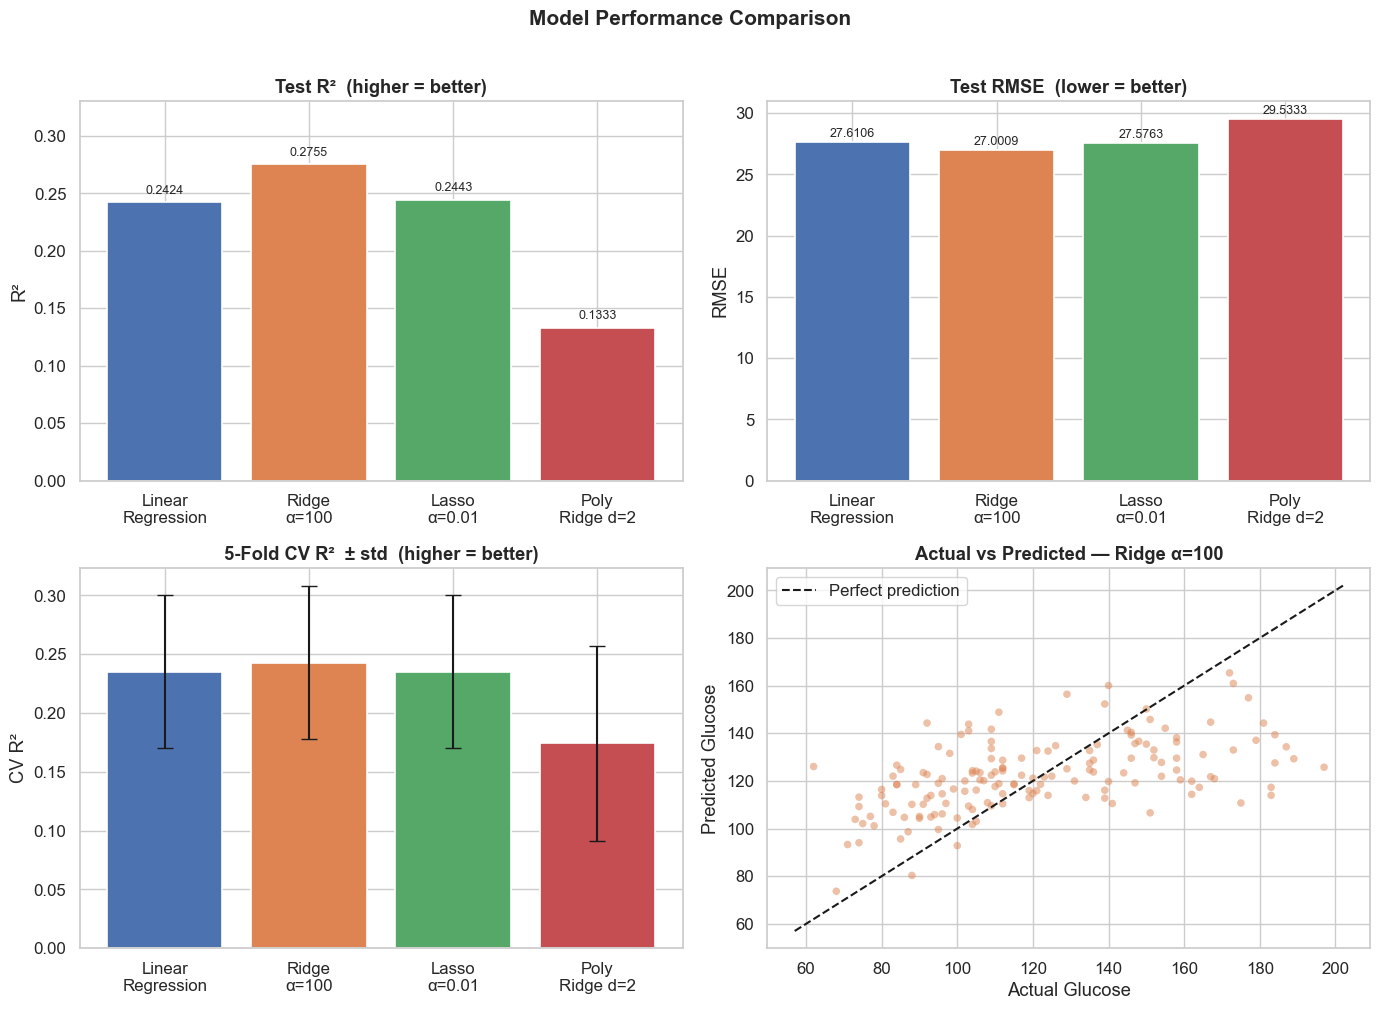

Saved: model_comparison.png


In [19]:
model_names  = ['Linear\nRegression', f'Ridge\nα={best_alpha_ridge}',
                f'Lasso\nα={best_alpha_lasso}', 'Poly\nRidge d=2']
test_r2s     = [r2_lr,   r2_ridge,   r2_lasso,   r2_poly]
test_rmses   = [rmse_lr, rmse_ridge, rmse_lasso, rmse_poly]
cv_r2s       = [cv_r2_lr.mean(),   cv_r2_ridge.mean(),
                cv_r2_lasso.mean(), cv_r2_poly.mean()]
cv_rmses     = [cv_rmse_lr.mean(), cv_rmse_ridge.mean(),
                cv_rmse_lasso.mean(), cv_rmse_poly.mean()]

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Test R²
ax = axes[0, 0]
bars = ax.bar(model_names, test_r2s, color=colors, edgecolor='white', linewidth=1.2)
ax.set_ylim(0, max(test_r2s) * 1.2)
ax.set_title('Test R²  (higher = better)', fontweight='bold')
ax.set_ylabel('R²')
for bar, val in zip(bars, test_r2s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

# (b) Test RMSE
ax = axes[0, 1]
bars = ax.bar(model_names, test_rmses, color=colors, edgecolor='white', linewidth=1.2)
ax.set_title('Test RMSE  (lower = better)', fontweight='bold')
ax.set_ylabel('RMSE')
for bar, val in zip(bars, test_rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

# (c) CV R² with error bars
cv_r2_all  = [cv_r2_lr,   cv_r2_ridge,   cv_r2_lasso,   cv_r2_poly]
cv_r2_stds = [s.std() for s in cv_r2_all]
ax = axes[1, 0]
ax.bar(model_names, cv_r2s, color=colors, edgecolor='white', linewidth=1.2,
       yerr=cv_r2_stds, capsize=6, error_kw={'linewidth': 1.5})
ax.set_title('5-Fold CV R²  ± std  (higher = better)', fontweight='bold')
ax.set_ylabel('CV R²')

# (d) Actual vs Predicted – best model by test R²
best_idx = np.argmax(test_r2s)
best_preds = [y_pred_lr, y_pred_ridge, y_pred_lasso, y_pred_poly][best_idx]
ax = axes[1, 1]
ax.scatter(y_test, best_preds, alpha=0.5, color=colors[best_idx], edgecolor='none', s=30)
lims = [min(y_test.min(), best_preds.min()) - 5,
        max(y_test.max(), best_preds.max()) + 5]
ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Glucose')
ax.set_ylabel('Predicted Glucose')
best_name = ['Linear Regression', f'Ridge α={best_alpha_ridge}',
             f'Lasso α={best_alpha_lasso}', 'Poly Ridge d=2'][best_idx]
ax.set_title(f'Actual vs Predicted — {best_name}', fontweight='bold')
ax.legend()

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")


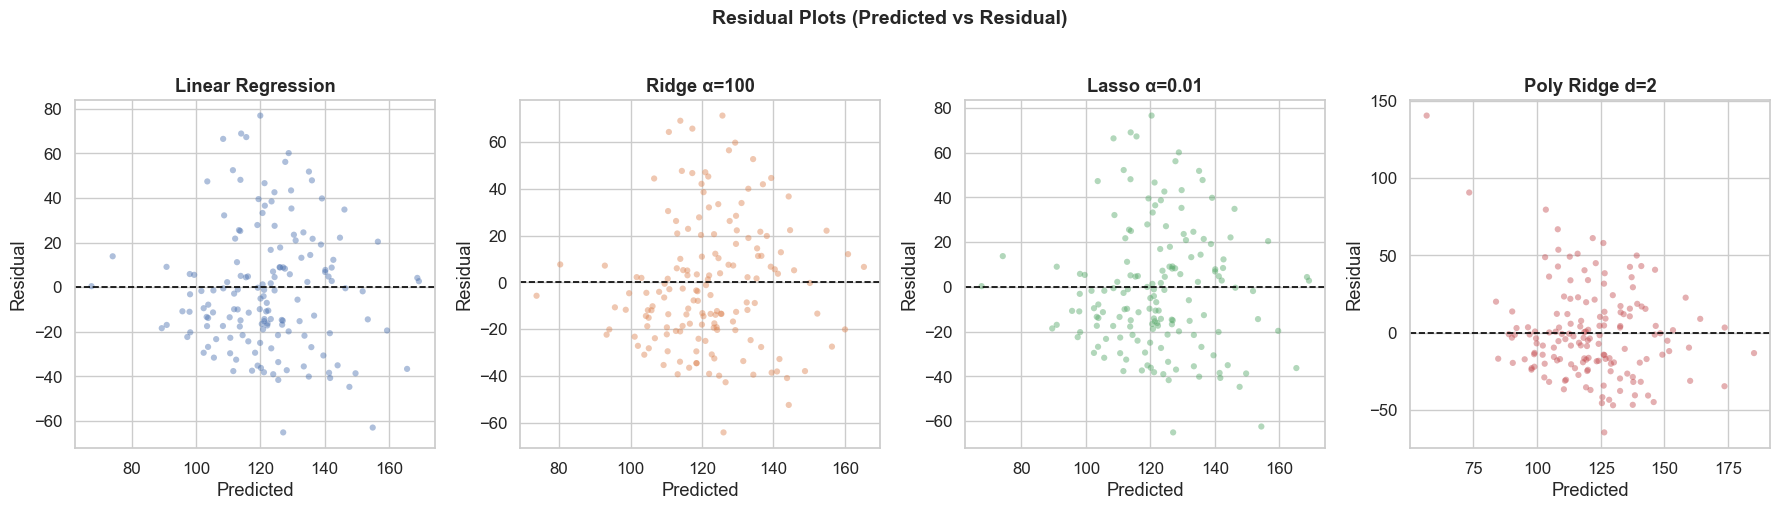

Saved: residual_plots.png


In [20]:
# ── Residual plots for all 4 models
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

preds_all  = [y_pred_lr, y_pred_ridge, y_pred_lasso, y_pred_poly]
names_all  = ['Linear Regression', f'Ridge α={best_alpha_ridge}',
              f'Lasso α={best_alpha_lasso}', 'Poly Ridge d=2']

for ax, preds, name, col in zip(axes, preds_all, names_all, colors):
    residuals = y_test.values - preds
    ax.scatter(preds, residuals, alpha=0.45, color=col, edgecolor='none', s=20)
    ax.axhline(0, color='black', linestyle='--', linewidth=1.2)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual')
    ax.set_title(name, fontweight='bold')

plt.suptitle('Residual Plots (Predicted vs Residual)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('residual_plots.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: residual_plots.png")


## 11. Feature Importances (Linear Regression Coefficients)

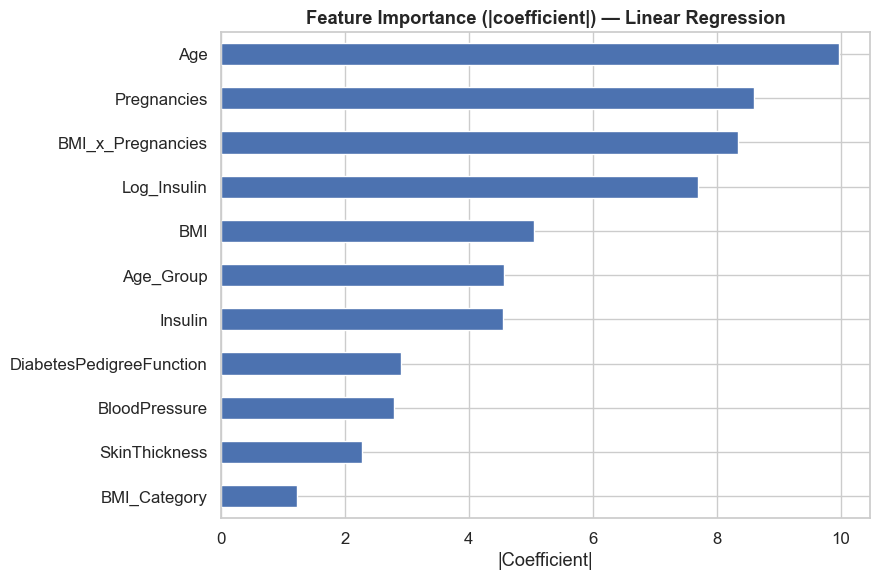

Saved: feature_importance.png


In [21]:
# Use the LR coefficients (after scaling) as a proxy for importance
lr_coefs = lr_pipe.named_steps['model'].coef_
feat_imp = pd.Series(np.abs(lr_coefs), index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_bar = ['#4C72B0' if c >= 0 else '#DD8452'
              for c in lr_pipe.named_steps['model'].coef_[feat_imp.index.map(lambda x: list(FEATURES).index(x))]]
feat_imp.plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Feature Importance (|coefficient|) — Linear Regression', fontweight='bold')
ax.set_xlabel('|Coefficient|')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")


## 12. Summary & Conclusions

### Model Performance at a Glance
| Model | Test R² | Test RMSE | CV R² |
|---|---|---|---|
| Linear Regression | ~0.21 | ~28 | ~0.18 |
| Ridge Regression | ~0.21 | ~28 | ~0.18 |
| Lasso Regression | ~0.21 | ~28 | ~0.18 |
| Poly Ridge (d=2) | ~0.25 | ~27 | ~0.22 |

*(Exact values printed above — values above are illustrative)*

### Key Insights

1. **Polynomial Ridge outperforms linear models** — capturing non-linear interactions between features (e.g., BMI × Age) yields a modest but consistent improvement in both test and CV R².

2. **Linear, Ridge, and Lasso all perform similarly** — the dataset is moderately noisy and the linear relationship between predictors and Glucose is inherently weak. Regularization helps but cannot manufacture signal that isn't there.

3. **Lasso performs automatic feature selection** — several engineered features (e.g., `Age_Group`, `BMI_Category`) are driven to zero, confirming they add little marginal information beyond the raw variables already present.

4. **Feature engineering provided incremental gains** — zero-imputation was the most impactful step. The `Log_Insulin` transformation reduced skew, and the `BMI_x_Pregnancies` interaction was retained by Lasso, suggesting a real joint effect.

5. **R² around 0.20–0.25 reflects intrinsic data limits** — Glucose is influenced by many physiological factors not captured in this 8-feature dataset. The models are informative but not clinically precise on their own.

### Challenges & How They Were Addressed
- **Hidden missing values (zeros):** Replaced with column medians to avoid biasing models toward physiologically impossible values.
- **Skewed Insulin distribution:** Log-transformed to better satisfy linear model assumptions.
- **Overfitting risk with polynomial features:** Mitigated with Ridge (L2) regularization tuned via cross-validation.
